# B18a · Context as deployed model state

Portable student lab. The default path reconstructs saved evidence and executes your own state/explanation functions. Fresh inference is a separate opt-in GPU cell. No paper-result reproduction or learner mastery is inferred. Allow 45–60 minutes.

**Prerequisites:** NumPy arrays, support/query split, probability versus label. B18 showed why missing context matters; here we track how a changed context changes a deployed predictor.

**Recall:** When is a label available? Why can fixed weights produce changed predictions?

<figure class="state-figure" tabindex="0" role="region" aria-label="TACO compressor, latent context and predictor, with explicit query path.">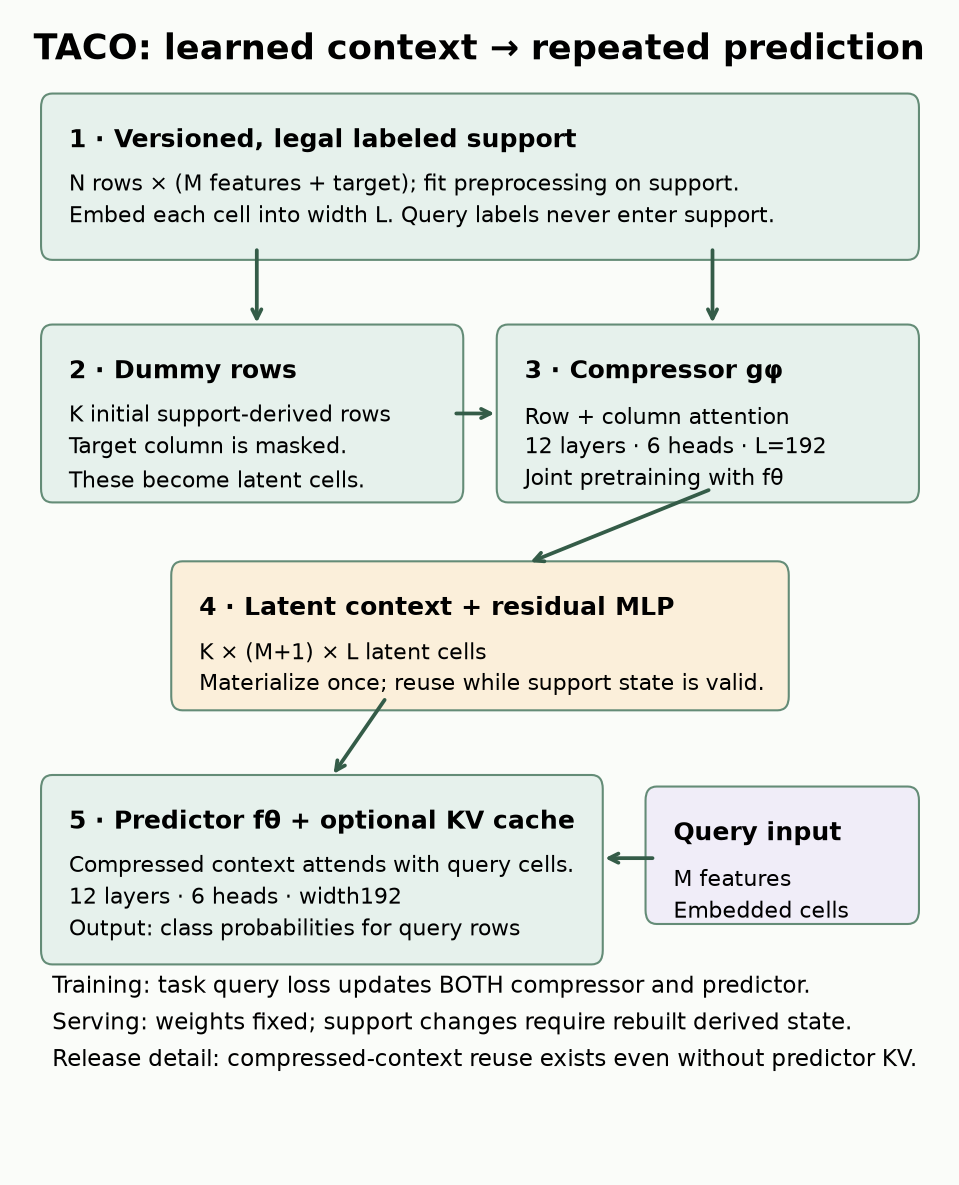<figcaption>TACO compressor, latent context and predictor, with explicit query path. <span class="state-scroll-hint">On small screens, swipe the figure or focus it and use arrow keys.</span></figcaption></figure>

## Setup

Python3.10–3.12, NumPy and scikit-learn are needed for replay. If absent, install `numpy==2.2.6 scikit-learn==1.6.1`. Fresh inference uses the separately pinned GPU environment. Figures and the source/evidence packet are embedded; no repository or filesystem path is needed.

In [ ]:
import base64,hashlib,io,json,zipfile
from pathlib import Path
import numpy as np
from sklearn.metrics import roc_auc_score,log_loss
packet=Path("b18a-packet");packet.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(base64.b64decode('...'))) as z:
    z.extractall(packet)
parts=[json.loads((packet/"evidence/b18a"/(p+".json")).read_text()) for p in ["pilot","matrix","updates"]]
data=parts[0]["data"]
X=np.asarray(data["x"]);y=np.asarray(data["y"]);train=np.asarray(data["train"]);test=np.asarray(data["test"])
assert not set(train)&set(test)
print(len(train), "support;",len(test),"query rows. Saved inference; no new model fitted.")

## TODO1 · A row needs event, arrival AND label availability by the cutoff. Reject duplicate IDs.

In [ ]:
def eligible_support(rows, cutoff):
    raise NotImplementedError("Implement eligible_support")

In [ ]:
rows=[dict(id=1,event=1,available=2,label_available=5),dict(id=2,event=1,available=6,label_available=2)]
assert [r['id'] for r in eligible_support(rows,5)]==[1]
try: eligible_support(rows+[rows[0]],9)
except ValueError: pass
else: raise AssertionError('Duplicate IDs accepted')
print("CHECK passed: eligible_support")

## TODO2 · Hash ordered IDs, features including explicit NaN positions, labels, weights, fitted preprocessing identity and inference recipe. Return a deterministic hexadecimal SHA256.

In [ ]:
def state_key(*, ids, x, y, weights, preprocessing, recipe):
    raise NotImplementedError("Implement state_key")

In [ ]:
args=dict(ids=[1,2],x=np.array([[1.,np.nan],[2.,3.]]),y=[0,1],weights='abc',preprocessing={'scale':1},recipe={'seed':0})
a=state_key(**args)
assert len(a)==64 and a==state_key(**args)
for key,value in [('y',[1,1]),('ids',[2,1]),('weights','def'),('preprocessing',{'scale':2}),('recipe',{'seed':1}),('x',np.nan_to_num(args['x']))]:
    assert a!=state_key(**dict(args,**{key:value})),key
print("CHECK passed: state_key")

## TODO3 · Implement f(x)−mean_b f(x with feature j replaced by background b_j). Preserve other query features; one result per query.

In [ ]:
def replacement_contrast(predict, x, background, feature):
    raise NotImplementedError("Implement replacement_contrast")

In [ ]:
calls=[]
def oracle(q):
    calls.append(len(q));return q[:,0]+2*q[:,1]
effect=replacement_contrast(oracle,np.array([[4.,2.],[6.,1.]]),np.array([[1.,8.],[3.,9.]]),0)
np.testing.assert_allclose(effect,[2,4]);assert sum(calls)==6
print("CHECK passed: replacement_contrast")

## Replay all 18 fits

Use every seed/arm/cache condition. Do not select the best test score. Three seeds on one split do not create three independent datasets.

In [ ]:
records=parts[0]['records']+parts[1]['records']
assert len(records)==18
for row in records:
    p=np.asarray(row['predictions']);assert p.shape==(4,285)
    auc=roc_auc_score(y[test],p[0]);loss=log_loss(y[test],p[0])
    assert abs(auc-row['auc'])<1e-12 and abs(loss-row['log_loss'])<1e-12
    print(row['seed'],row['arm'],row['mode'],round(auc,6),round(loss,6))
for seed in [0,1,2]:
    for arm in ['POT-full','POT-selected','TACO4']:
        pair=[r for r in records if r['seed']==seed and r['arm']==arm]
        delta=np.max(np.abs(np.asarray(pair[0]['predictions'])-np.asarray(pair[1]['predictions'])))
        print('cache agreement',seed,arm,delta,'PASS' if delta<=1e-5 else 'FAIL')

<figure class="state-figure" tabindex="0" role="region" aria-label="Author measurements: quality and repeated inference cost on one frozen split.">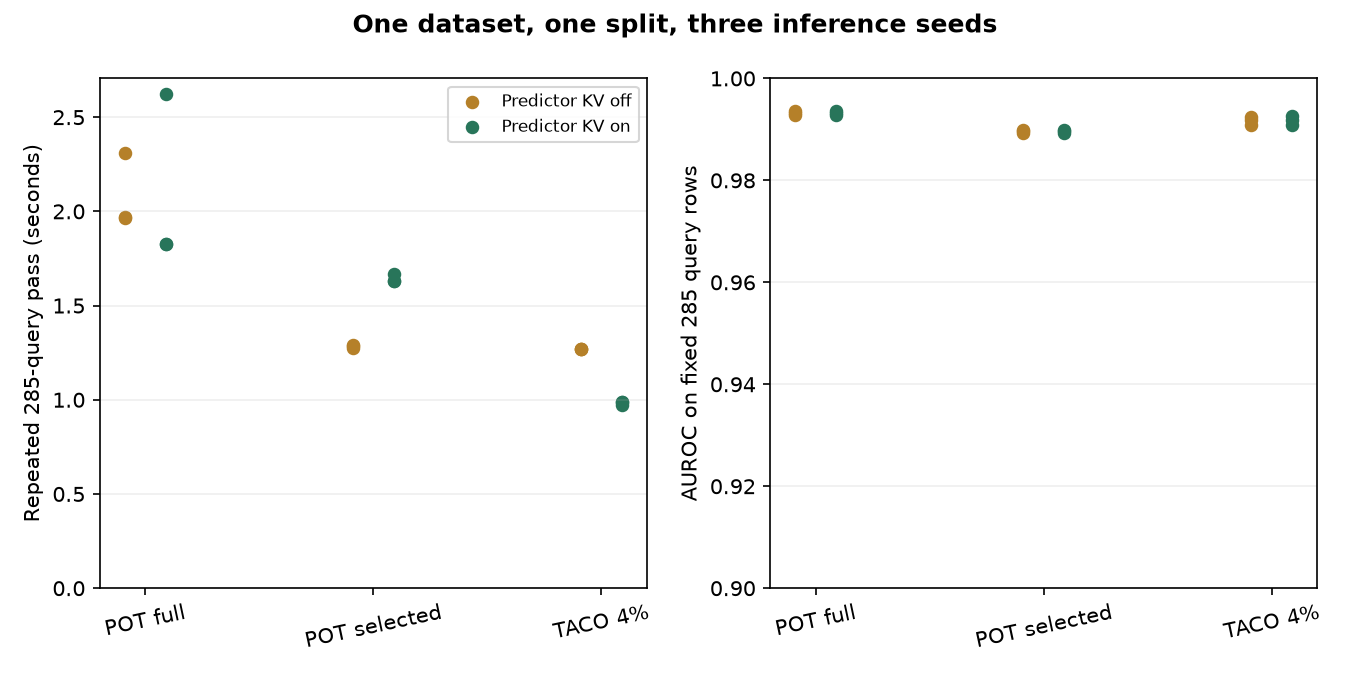<figcaption>Author measurements: quality and repeated inference cost on one frozen split. <span class="state-scroll-hint">On small screens, swipe the figure or focus it and use arrow keys.</span></figcaption></figure>

## Use your identity function on real support updates

A change in identity requires checking dependent artifacts even if probabilities happen to be equal. Query missingness alone does not change support identity.

In [ ]:
base=train[1:];ids=base.tolist()
args=dict(ids=ids,x=X[base],y=y[base],weights='fixed-checkpoint',preprocessing={'version':1},recipe={'seed':0})
original=state_key(**args)
changed=y[base].copy();changed[0]=1-changed[0]
assert original!=state_key(**dict(args,y=changed))
assert original!=state_key(**dict(args,ids=ids[1:],x=X[base[1:]],y=y[base[1:]]))
assert original==state_key(**args)
for row in parts[2]['updates']:
    baseline=next(q for q in parts[2]['updates'] if q['arm']==row['arm'] and q['intervention']=='baseline')
    delta=np.max(np.abs(np.asarray(row['predictions'])-baseline['predictions']))
    print(row['arm'],row['intervention'],round(float(delta),6))

<figure class="state-figure" tabindex="0" role="region" aria-label="Predictive support, query and explanation background have separate identities.">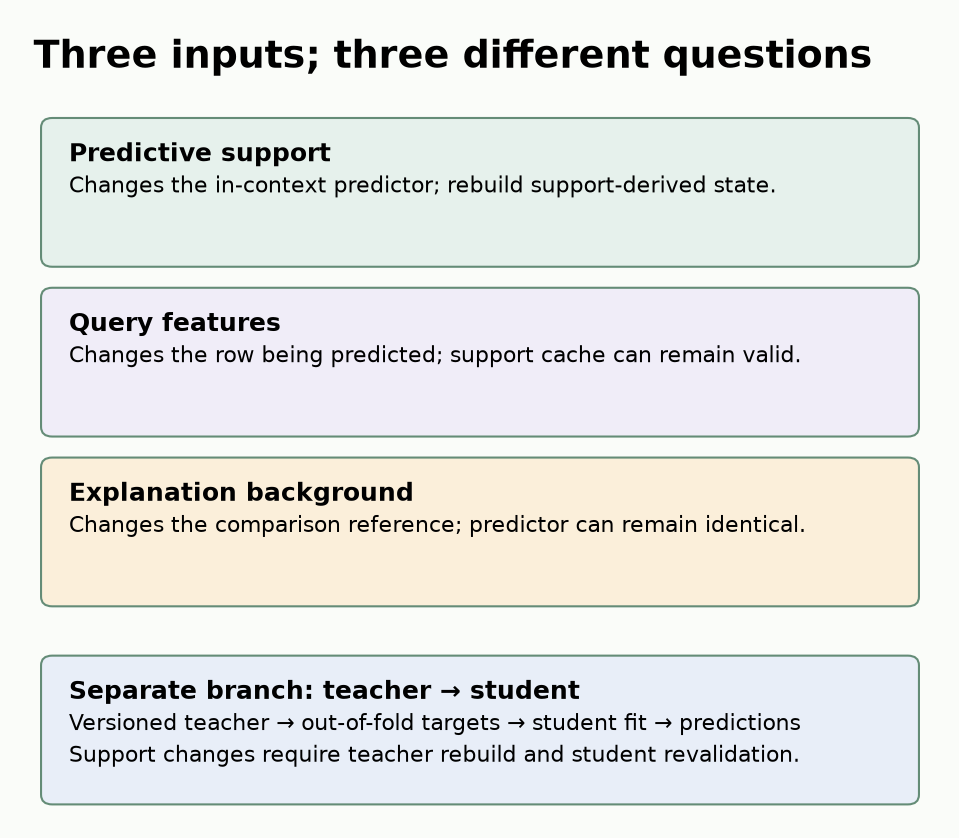<figcaption>Predictive support, query and explanation background have separate identities. <span class="state-scroll-hint">On small screens, swipe the figure or focus it and use arrow keys.</span></figcaption></figure>

## Replay explanations using your replacement function

The lookup accepts only the exact saved query arrays; wrong feature replacement cannot accidentally return the right answer. This is a descriptive contrast, not SHAP or causality.

In [ ]:
for explanation in parts[2]['explanations']:
    def saved_predict(q):
        for call in explanation['calls']:
            if np.array_equal(q,np.asarray(call['x'])):return np.asarray(call['p'])
        raise AssertionError('Requested unsaved/wrong intervention rows')
    live=replacement_contrast(saved_predict,X[explanation['query_ids']],X[explanation['background_ids']],0)
    np.testing.assert_allclose(live,explanation['effects'],atol=1e-12,rtol=0)
    print(explanation['arm'],explanation['background'],float(live.mean()),'144 prediction rows')

## Visible full fresh-inference operator

The archived release provides the pretrained architecture; this complete operator defines all data selection, seeds, modes, timers, interventions and saved probabilities. It trains no new weights. Loading weights downloads two authenticated public checkpoint files. The source packet includes upstream model code/licenses, the exact Modal environment, and budget guard.

### Load-bearing released compressor code

Exact excerpts from the pinned source. Follow K selection → dummy features → emitted latent cells → residual projection → cached context → predictor. The complete cell-attention implementation is in the embedded source tarball. These are source excerpts, not newly trained course weights.

```python
def _sample_keep_count(self, train_size: int) -> int:
        if self.rcp_sampling == "uniform" and self.rcp_choices:
            p = float(random.choice(self.rcp_choices))
        else:
            p = self.row_compression_percentage
        K = math.ceil(train_size * p / 100.0)
        return max(self.rcp_k_min, min(K, train_size))

def _compress_latents(self, X: Tensor, y_train: Tensor, train_size: int):
        """
        Returns:
          compressed_ctx: (B, K, F + 1, Ec)
          K: int
        """
        assert self.use_compressor, "Compressor disabled."
        assert train_size <= X.shape[1]
        B, T, F = X.shape
        K = self._sample_keep_count(train_size)

        self.compressor = self.compressor.to(X.device)
        x_train = X[:, :train_size, :].transpose(0, 1)
        x_queries = X[:, train_size - K:train_size, :].transpose(0, 1)
        x_for_comp = torch.cat([x_train, x_queries], dim=0)
        y_for_comp = y_train[:, :train_size].to(X.dtype).transpose(0, 1)
        compressed_ctx = self.compressor.emit_context(
            x=x_for_comp,
            y=y_for_comp,
            single_eval_pos=train_size,
            source="test",
        )


        return compressed_ctx, K
```

```python
"""Pinned release inference; no training, HPO, or implicit protocol reduction."""
import gc,hashlib,json,os,platform,random,time,traceback
from pathlib import Path
import numpy as np
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,log_loss
from taco.model.tabpfn_arch.taco_classifier import TACOClassifier
from state_b18a import state_key,replacement_contrast

HF='d38ed9517764698a0b0064a7a8cb4197016349a3'
HASHES={'TACO':'bb1735869c5e995370ac6c1d8d7e2d27701fe35dbdb5c328565278d9d024471e','POT':'230330a87a629d0f505557863489341f50b0d059fb8cc241c2cca725cdb14963'}

def run(phase):
    import sklearn
    from huggingface_hub import hf_hub_download
    start=time.monotonic();out=dict(phase=phase,status='INCOMPLETE',records=[],updates=[],explanations=[])
    try:
        torch.set_num_threads(2);torch.backends.cuda.matmul.allow_tf32=False;torch.backends.cudnn.allow_tf32=False
        out['environment']=dict(torch=torch.__version__,sklearn=sklearn.__version__,numpy=np.__version__,gpu=torch.cuda.get_device_name(),python=platform.python_version())
        paths={}
        for name in ['POT','TACO']:
            p=hf_hub_download('zabergjg/TabPFN-TACO',f'TabPFN-{name}-classifier.ckpt',revision=HF)
            assert hashlib.sha256(Path(p).read_bytes()).hexdigest()==HASHES[name]
            paths[name]=p
            ck=torch.load(p,map_location='cpu',weights_only=False)
            out.setdefault('checkpoint_metadata',{})[name]={k:repr(v)[:12000] for k,v in ck.items() if k in ['config','step','epoch','iteration','train_config']}
            del ck
        X,y=load_breast_cancer(return_X_y=True)
        train,test=train_test_split(np.arange(len(y)),test_size=.5,random_state=42,stratify=y)
        selected,_=train_test_split(train,train_size=.25,random_state=42,stratify=y[train])
        out['data']=dict(x=X.tolist(),y=y.tolist(),train=train.tolist(),test=test.tolist(),selected=selected.tolist(),sha256=hashlib.sha256(X.tobytes()+y.tobytes()).hexdigest())
        def sync():torch.cuda.synchronize()
        def make(arm,seed,mode,ids,values=X,labels=y):
            random.seed(seed);np.random.seed(seed);torch.manual_seed(seed);torch.cuda.manual_seed_all(seed)
            gc.collect();torch.cuda.empty_cache();torch.cuda.reset_peak_memory_stats();sync();t=time.monotonic()
            model=TACOClassifier(use_compressor=arm=='TACO4',row_compression_percentage=4,
                checkpoint_path=paths['TACO' if arm=='TACO4' else 'POT'],device='cuda',
                fit_mode=mode,n_estimators=8,random_state=seed,inference_precision=torch.float32,n_jobs=1)
            model.fit(values[ids],labels[ids]);sync()
            rec=dict(arm=arm,seed=seed,mode=mode,fit_seconds=time.monotonic()-t,support_ids=ids.tolist(),engine=type(model.executor_).__name__)
            rec['state_key']=state_key(ids=ids.tolist(),x=values[ids],y=labels[ids],weights=HASHES['TACO' if arm=='TACO4' else 'POT'],preprocessing={'implementation':'pinned release','fit_rows':ids.tolist()},recipe={'seed':seed,'mode':mode,'estimators':8,'compression':4,'dtype':'float32','batch':50})
            rec['effective_compressor']=model.model_.core.use_compressor
            return model,rec
        def predict(model,queries,repeats=1):
            predictions=[];times=[]
            for rep in range(repeats):
                pieces=[];rt=[]
                for batch in range(0,len(queries),50):
                    sync();t=time.monotonic();p=model.predict_proba(queries[batch:batch+50])[:,1];sync()
                    rt.append(time.monotonic()-t);pieces.extend(p.astype(float).tolist())
                predictions.append(pieces);times.append(rt)
            return predictions,times
        pairs=[(s,a,m) for s in [0,1,2] for a in ['POT-full','POT-selected','TACO4'] for m in ['fit_preprocessors','fit_with_cache']]
        chosen=[p for p in pairs if (p[0]==0 and p[1]=='POT-full')==(phase=='pilot')] if phase in ['pilot','matrix'] else []
        for seed,arm,mode in chosen:
            ids=selected if arm=='POT-selected' else train
            model,rec=make(arm,seed,mode,ids)
            pred,times=predict(model,X[test],4)
            rec.update(predictions=pred,batch_seconds=times,auc=roc_auc_score(y[test],pred[0]),log_loss=log_loss(y[test],pred[0]),peak_allocated_bytes=torch.cuda.max_memory_allocated(),post_predict_allocated_bytes=torch.cuda.memory_allocated(),K_values=getattr(model,'K_values_',None))
            out['records'].append(rec);print(phase,seed,arm,mode,rec['auc'],sum(map(sum,times)),flush=True)
            del model;gc.collect();torch.cuda.empty_cache()
        if phase=='updates':
            # Baseline reserves one SUPPORT row for the addition test.
            base=train[1:];add_id=int(train[0])
            variants=[('baseline',base,X,y),('add',train,X,y),('delete',base[1:],X,y)]
            flip=y.copy();flip[base[0]]=1-flip[base[0]];variants.append(('label',base,X,flip))
            scaled=X.copy();scaled[:,0]*=10;variants.append(('units',base,scaled,y))
            for arm in ['POT-full','TACO4']:
                for label,ids,values,labels in variants:
                    model,rec=make(arm,0,'fit_with_cache',ids,values,labels)
                    pred,times=predict(model,values[test]);rec.update(intervention=label,predictions=pred[0],batch_seconds=times,auc=roc_auc_score(y[test],pred[0]),peak_allocated_bytes=torch.cuda.max_memory_allocated())
                    out['updates'].append(rec)
                    if label=='baseline':
                        masked=X[test].copy();masked[:57,0]=np.nan
                        mp,mt=predict(model,masked);out['updates'].append(dict(arm=arm,intervention='query_missing',predictions=mp[0],batch_seconds=mt,support_ids=ids.tolist(),state_key=rec['state_key'],auc=roc_auc_score(y[test],mp[0])))
                        for bgname,bg in [('first8',base[:8]),('last8',base[-8:])]:
                            calls=[]
                            def prob(q):
                                p,t=predict(model,q);calls.append(dict(x=q.tolist(),p=p[0],seconds=t));return np.array(p[0])
                            effects=replacement_contrast(prob,X[test[:16]],X[bg],0)
                            out['explanations'].append(dict(arm=arm,background=bgname,background_ids=bg.tolist(),query_ids=test[:16].tolist(),feature=0,effects=effects.tolist(),calls=calls))
                    del model;gc.collect();torch.cuda.empty_cache()
        out['status']='COMPLETE'
    except Exception:
        out['error']=traceback.format_exc();print(out['error'],flush=True)
    out['seconds']=time.monotonic()-start
    return out

```

## Optional fresh GPU run

Default false: replay does not trigger downloads or paid execution. On a compatible GPU runtime, install the packet tarball and pinned dependencies listed in `_cloud_b18a.py`; run the complete three phases below. This performs fresh inference and may take minutes. Local execution here has no Modal billing guard; use the provided budgeted cloud operator for paid execution. Preserve output files and count all attempts. No reduced dataset or fewer ensemble members is substituted.

In [ ]:
RUN_FRESH=False
if RUN_FRESH:
    import sys,shutil
    sys.path.insert(0,str(packet.resolve()))
    shutil.copy(packet/'relkit/state_b18a.py',packet/'state_b18a.py')
    from _experiment_b18a import run
    for phase in ['pilot','matrix','updates']:
        result=run(phase)
        Path('fresh-'+phase+'.json').write_text(json.dumps(result))
        assert result['status']=='COMPLETE',result.get('error')
else:
    print('Fresh notebook inference NOT_RUN. Author GPU evidence is separately archived.')

## Historical Figure3 gate

Audit success means source-byte identity only. Missing original generator, seeds, checkpoint mapping and timing identity prevent historical reproduction. Full pretraining and TabArena paper evaluations remain NOT_RUN.

In [ ]:
import subprocess,sys
audit=subprocess.run([sys.executable,str(packet/'_reproduce_b18a.py'),'--phase','audit'],capture_output=True,text=True,check=True)
print(audit.stdout)
blocked=subprocess.run([sys.executable,str(packet/'_reproduce_b18a.py'),'--phase','paper'],capture_output=True,text=True)
assert blocked.returncode!=0 and 'INCOMPLETE_SOURCE_PROTOCOL_GATE' in blocked.stderr
print(blocked.stderr)

## EXIT · written defense

In 150–200 words, identify the deployed predictor, trace a late label correction, explain why query-only and background-only changes differ, interpret one observed cache agreement result, and specify an update-frequency/quality/cost falsification test for B23/B24.

Teacher targets for a distilled student must exclude each row’s own label and respect availability time; no student is trained here. Ask your teacher for feedback. Revisit tomorrow, in 7 days and 30 days. Learner status remains PENDING_WRITTEN_DEFENSE.

Primary sources: [TACO](https://arxiv.org/html/2602.05649v2), [TabPFN2.5](https://arxiv.org/html/2511.08667v2), [Interpretation](https://arxiv.org/html/2403.10923v2).